# Event Studies and More on Difference-in-Differences

files needed = ('public.dat', 'sw06.csv')

In our basic 2x2 diff-in-diffs example, all control units (PA) never receive the treatment, while all treatment units (NJ) receive the treatment *at the exact same time* (when the law changed in 1992).

There are several reasons why we might want to develop tools to look beyond this simple 2x2 analysis:

1. We might want to test the parallel trends assumption by examining *pre-trends*. Note that this requires more than one pre-treatment period.
2. We might want to explore post-treatment *dynamics*. Are the effects of treatment delayed, or short-lived?
3. What if we have multiple treatment units that received the treatment *at different times*? This larger sample may give us greater statistical power, but choosing and interpreting the appropriate model is not always as straightforward as with the standard difference-in-differences setup. 

In [5]:
import pandas as pd
import numpy as np
from pandas import option_context
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf 
import os
os.chdir('/Users/jackson/Documents/ECON570')

### Parallel trends revisited

Recall our illustration of the parallel trends assumption in the minimum wage example. Event study specifications allow us to compare pre-treatment trends in the treatment and control group across *multiple* pre-treatment periods. We might feel more confident that the control group is valid if outcomes in the treatment and control group were trending similarly prior to treatment. 

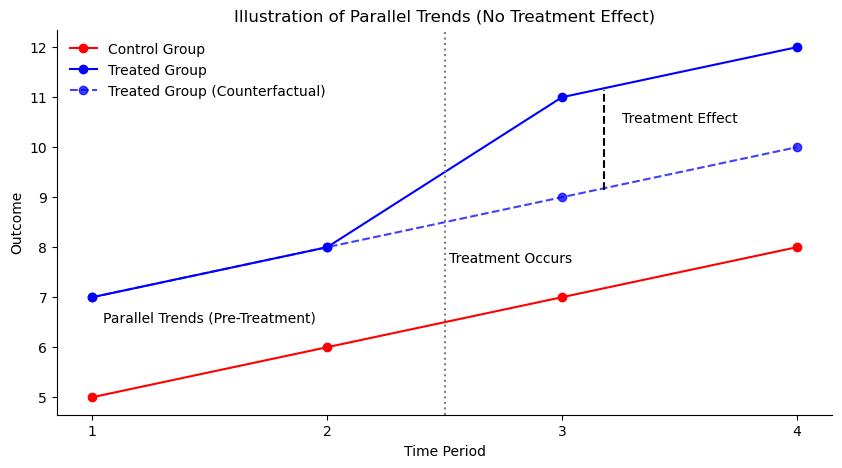

In [6]:
fig, ax = plt.subplots(figsize=(10,5)) 

# Time periods
periods = [1, 2, 3, 4]

# Control group outcomes (no treatment effect)
control = [5, 6, 7, 8]

# Treated group outcomes
# Start at 7 and follow same slope as control throughout (parallel trends everywhere)
treated_cf = [7, 8, 9, 10]  # No treatment effect — same trend as control, just higher
treated = [7, 8, 11, 12] # Treatment effect

ax.plot(periods, control, label='Control Group', marker='o', color='red')
ax.plot(periods, treated, label='Treated Group', marker='o', color='blue')
ax.plot(periods, treated_cf, label='Treated Group (Counterfactual)', marker='o', alpha=.75, linestyle='--', color='blue')

# Add vertical line to indicate treatment timing
ax.axvline(x=2.5, color='gray', linestyle=':')

ax.text(1.5, 6.5, 'Parallel Trends (Pre-Treatment)', ha='center', fontsize=10)
ax.plot([3.18, 3.18], [9.15, 11.15], color='black', lw=1.5, linestyle='--')  # line above period 1 and 2
ax.text(3.5, 10.5, 'Treatment Effect', ha='center', fontsize=10)
ax.text(2.52, 7.7, 'Treatment Occurs', fontsize=10)

# Annotate
ax.set_title('Illustration of Parallel Trends (No Treatment Effect)')
ax.set_xlabel('Time Period')
ax.set_ylabel('Outcome')
ax.legend(frameon=False)
ax.xaxis.set_ticks(periods)

sns.despine(ax=ax)

plt.show()

If we establish that pre-trends are indeed parallel, does our identification assumption change?

## Implementation

We'll start by replicating an event study in another published paper. [Here](https://www.aeaweb.org/articles?id=10.1257/jep.37.2.203) is a very accessible overview of this method.

We'll consider the following example. No-fault divorce laws were put in place at different times across different U.S. states. [Stevenson and Wolfers (2006)](http://users.nber.org/~jwolfers/Papers/bargaining_in_the_shadow_of_the_law.pdf) use these time-varying policy changes to estimate the effect of no-fault divorce laws on female suicide rates. For discussion of how the below could be implemented in Stata, see [here](https://www.damianclarke.net/research/papers/panelEvent.pdf).

We will reframe the data relative to the appropriate state law change (reframing the years in "event time"). The standard event studies regression model is: $$y_{it} = \sum_{j=[-m,...,0,...,n]} \gamma_j D_{i,t-j} + \alpha_i + \delta_t + \beta X_{it} +\epsilon_{it} $$
In this context we have:
* `state` is indexed by $i$ and `year` is indexed by $t$
* $y_{it}$ is outcome `asmrs` in state $i$ and year $t$
* $D_{i,t−j}$ is an indicator variable for event time $j$. We'll choose how many years before ($m$) and how many years after ($n$) the state law change to examine. \[If `year` $t$ is $j$ years after `treat_year`, then $D_{i,t−j}=1$.  Otherwise, $D_{i,t−j}=0$.\]
* $\alpha_i$ and $\delta_t$ are `state` and `year` fixed effects; hence the common terminology "two way fixed effects (TWFE)"
* $X_{it}$ are (optional) controls: Per-Capita Income (`pcinc`), Homicide Mortality (`asmrh`) and the Aid to Families with Dependent Children (AFDC) rate for a family of four (`cases`)

Let's read in the data from the file 'sw06.csv'.

In [7]:
sw06 = pd.read_csv('data/sw06.csv')
sw06.sample(10)

,state,year,treat_year,asmrs,pcinc,asmrh,cases
739,28,1977,NaN,44.684444,18429.999190,6.117247,0.041489
836,31,1975,1972.0,51.291889,24681.399442,1.880171,0.015144
1209,42,1985,1980.0,43.172554,29110.202155,2.465867,0.030422
1103,39,1978,1974.0,55.891972,26545.861194,3.320178,0.030697
485,20,1987,1969.0,45.485817,30560.754557,2.353818,0.019708
321,13,1988,1973.0,47.798592,29617.995141,5.551299,0.027421
1533,54,1979,NaN,54.500702,21501.921210,4.223907,0.026482
1133,40,1975,NaN,71.343620,21954.965783,4.270500,0.020864
1069,38,1977,1971.0,24.665825,22713.318612,0.427190,0.015065
1090,39,1965,1974.0,63.741287,18918.742827,2.129043,0.008712


Let's create the lag/lead indicators for treated states. In the case of no law change (`treat_year == NaN`), we'll set the lag/lead to -1.

In [8]:
sw06['time_to_treat'] = (sw06['year'] - sw06['treat_year']).fillna(-1).astype('int')
sw06.sample(5)

,state,year,treat_year,asmrs,pcinc,asmrh,cases,time_to_treat
1458,51,1970,NaN,67.197479,21959.560245,4.089542,0.011221,-1
93,5,1991,NaN,34.793411,25107.006967,6.074876,0.021352,-1
527,21,1996,1972.0,34.120411,29477.889799,3.132477,0.035285,24
1417,49,1995,NaN,56.161442,28375.154719,2.452656,0.015985,-1
816,30,1988,1975.0,40.602512,24953.934830,2.644107,0.023528,13


Next, we'll choose our `time_to_treat` interval. We'll start our event time frame 10 years before the event and 20 years after.

In [9]:
sw06 = sw06[(sw06['time_to_treat'] >= -10) & (sw06['time_to_treat'] <= 20)]

Next, we'll create the $D_{i,t-j}$ indicators. I'm going to do this using `.get_dummies()`. We need to drop a reference category to avoid multicollinearity. Let's follow convention by skipping $t-j=-1$. This is the year before the state law takes effect. (Notice that we set all states with no law change to this reference category.) Now, the estimates on the remaining indicator variables should be interpreted relative to the year before the state law takes effect.

In [10]:
# create indicators for each time_to_treat instance
sw06 = pd.get_dummies(sw06, columns=['time_to_treat'], prefix='Di', dtype=int)
# get rid of the '-' in the column names
sw06.rename(columns=lambda x: x.replace('-', 'm'), inplace=True)
# drop t-j=-1
sw06.drop(columns='Di_m1', inplace=True)
sw06.sample(5)

,state,year,treat_year,asmrs,pcinc,asmrh,cases,Di_m10,Di_m9,Di_m8,...,Di_11,Di_12,Di_13,Di_14,Di_15,Di_16,Di_17,Di_18,Di_19,Di_20
665,26,1969,1972.0,61.907890,22636.817014,3.396548,0.012264,0,0,0,...,0,0,0,0,0,0,0,0,0,0
797,30,1969,1975.0,69.147942,18758.906768,2.041538,0.009290,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1506,53,1985,1973.0,57.104488,30387.714870,2.844349,0.029770,0,0,0,...,0,1,0,0,0,0,0,0,0,0
1154,40,1996,NaN,58.289715,29249.141840,3.297104,0.021650,0,0,0,...,0,0,0,0,0,0,0,0,0,0
215,10,1981,NaN,40.570492,28758.244742,5.315160,0.037351,0,0,0,...,0,0,0,0,0,0,0,0,0,0


Time to estimate the regression model. We'll use statsmodels.api. I'll build the key parts of the formula string first.

In [11]:
# build the formula
endog = 'asmrs'
indicators = sw06.columns[sw06.columns.str.contains('Di')]
controls = ['pcinc', 'asmrh', 'cases']

formula = '{} ~ {} + C(state) + C(year) + {}'.format(endog, '+'.join(indicators), '+'.join(controls))
print(formula)

asmrs ~ Di_m10+Di_m9+Di_m8+Di_m7+Di_m6+Di_m5+Di_m4+Di_m3+Di_m2+Di_0+Di_1+Di_2+Di_3+Di_4+Di_5+Di_6+Di_7+Di_8+Di_9+Di_10+Di_11+Di_12+Di_13+Di_14+Di_15+Di_16+Di_17+Di_18+Di_19+Di_20 + C(state) + C(year) + pcinc+asmrh+cases


Looks good. Let's estimate the regression and summarize the results.

In [12]:
event_res = smf.ols(formula, data=sw06).fit(cov_type='HC3')
print(event_res.summary())

                            OLS Regression Results                            
Dep. Variable:                  asmrs   R-squared:                       0.732
Model:                            OLS   Adj. R-squared:                  0.710
Method:                 Least Squares   F-statistic:                     31.83
Date:                Tue, 04 Nov 2025   Prob (F-statistic):          2.77e-305
Time:                        13:20:33   Log-Likelihood:                -5503.1
No. Observations:                1466   AIC:                         1.123e+04
Df Residuals:                    1352   BIC:                         1.184e+04
Df Model:                         113                                         
Covariance Type:                  HC3                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept          56.2472      5.021     

This is way too much to look at! A figure will be much easier to interpret. To get ready to make our figure, we'll store the coefficient estimates and the lower and upper 95% confidence intervals in a new DataFrame called `res`.

In [13]:
# Get coefficients and CIs
res = pd.concat([event_res.conf_int(alpha=0.05), event_res.params], axis = 1)
res.columns = ['lower_ci','upper_ci','est']
res

,lower_ci,upper_ci,est
Intercept,46.406422,66.087917,56.247169
C(state)[T.4],34.787496,45.755058,40.271277
C(state)[T.5],-9.115026,4.235590,-2.439718
C(state)[T.6],57.984955,80.628123,69.306539
C(state)[T.8],48.123145,61.462659,54.792902
...,...,...,...
Di_19,-18.248703,-4.928284,-11.588494
Di_20,-16.364177,-1.875305,-9.119741
pcinc,-0.001781,-0.000837,-0.001309
asmrh,0.148280,1.965835,1.057058


Let's pick out only the rows associated with our event time indicators and use some string methods to convert the $t-j$ values back to integers. Finally, we want to sort these $t-j$ values before plotting.

In [14]:
# We only want the indicators
res = res.filter(like='Di', axis=0)
# Turn the coefficient names back to numbers
res.index = (
    res.index
        .str.replace('Di_', '')
        .str.replace('m', '-')
        .astype('int')
        .rename('time_to_treat')
)
# sort the index
res_sorted = res.sort_index()
res_sorted

,lower_ci,upper_ci,est
time_to_treat,,,
-10,-9.656187,7.581853,-1.037167
-9,-12.653651,2.497955,-5.077848
-8,-10.014279,4.240248,-2.887016
-7,-8.808009,6.400961,-1.203524
-6,-7.268549,5.469697,-0.899426
-5,-9.342961,3.681465,-2.830748
-4,-6.107335,6.393614,0.143140
-3,-8.824691,4.077154,-2.373768
-2,-6.923328,5.763752,-0.579788


Time to plot! Let's use `.errorbar()` to represent the confidence intervals. \[Another common choice in this context is to represent the confidence intervals with `.fill_between()`\]

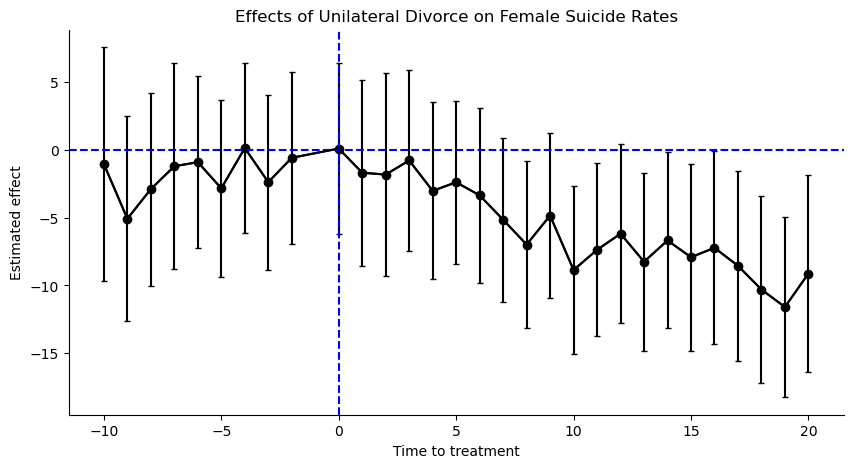

In [15]:
fig, ax = plt.subplots(figsize=(10,5)) 

ax.plot(res_sorted.index, res_sorted['est'], marker='o', color='black',)
ax.errorbar(res.index, res['est'], yerr=res['est']-res['lower_ci'], color='black',capsize=2)
# Alternative: Fill between
#ax.fill_between(res_sorted.index, res_sorted['lower_ci'], res_sorted['upper_ci'], color='blue', alpha=0.1) 

# Add a horizontal line at 0
ax.axhline(0, linestyle='dashed', color='blue')
# And a vertical line at the treatment time
ax.axvline(0, linestyle='dashed', color='blue')

sns.despine(ax=ax)
ax.set_title('Effects of Unilateral Divorce on Female Suicide Rates')
ax.set_xlabel('Time to treatment')
ax.set_ylabel('Estimated effect')

plt.show()

What did we learn?

* Before the law change, our estimates are not significantly different from zero. This is sometimes referred to as a "placebo" or "pre-trends" test. We verify that we don't see significant effects or patterns before treatment.
* Immediatedly after the law change, we don't see significant results.
* Over time, the estimates diverge from zero. After about 10 years, the estimates are consistently negative and significant.

The event study model enabled us to take a time-varying treatment of interest and generate a visual representation of a dynamic treatment effect. What is the equivalence between the standard DiD and the event study? Can you guess what the DiD estimate would be based on this figure?

After TWFE event studies began to proliferate, econometrics and applied researchers demonstrated some pitfalls of the method, especially when treatment effects are dynamic and treatment occurs in multiple periods. If you're interested in learning more about different strategies for estimating difference-in-differences models in such cases, see [here](https://arxiv.org/pdf/2503.13323) and come talk to me!

## Practice
We'll practice our event study tools by tweaking the pre/post time horizon. Then, we'll return to the DiD analysis. 

First, let's reestimate the event study for a different time horizon. I will walk you through this step by step.

1. Reopen the raw data. Recreate the `time_to_treat` variable, assigning a value -1 for all observations that are never treated, and drop observations with `time_to_treat`<-5 or `time_to_treat`>15. While you're at it, create a `post` indicator for observations with `time_to_treat`>-1.

2. Generate the relative time to treat indicators.

3. Build the formula for the event study and fit it using `statsmodels`. Create a DataFrame that contains the point estimates and upper and lower bounds of the 95% confidence interval.

4. Plot the estimates and 95% confidence interval for the event study. To mix things up, use the "fill between" option to color in the confidence intervals rather than using vertical bars. Does the figure look how you would expect, given the one we fit before?

5. Estimate a difference-in-differences model comparing the post-period \[0,15\] to the pre-period \[-5,-1\]. Interpret the results.

*Question:* If you were not going to estimate the event study, would you have created the `post` variable in the same way?